<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 138 &#183; Take It Further</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">A Paired Pre/Post Study: Take It Further</div>
  <div style="font-size:15px;color:#cffafe;max-width:740px;line-height:1.6">Five extensions of the Chapter 138 analysis: a counterbalancing check, a ladder of paired tests from sign to t, a bootstrap interval, the power of pairing by simulation, and a look at who did and did not benefit.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
EM="#0891b2"; DEEP="#0e7490"; LIGHT="#a5f3fc"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; GREEN="#059669"; GREY="#94a3b8"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/case-study-a-paired-pre-post-study--ux_redesign.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"case-study-a-paired-pre-post-study--ux_redesign.xlsx", sheet_name="Data")
df["diff"] = df.new_design_seconds - df.old_design_seconds
rng = np.random.default_rng(138)
print(f"mean difference (new - old) = {df['diff'].mean():.2f} s over {len(df)} users")

mean difference (new - old) = -9.29 s over 45 users


<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">EXTENSION 1</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Did the order matter?</div>
<div style="color:#4a5578;margin-top:6px">Counterbalancing only helps if you check it.</div>
</div>

The study counterbalanced which design each user saw first, precisely so that practice with the task could not masquerade as a design effect. But counterbalancing is a safeguard, not a guarantee, so we test it: does the improvement differ between users who saw the **old** design first and those who saw the **new** one first? If order were driving the result, those two groups would show very different differences.

In [2]:
g = df.groupby("first_design")["diff"]
print(g.agg(['size','mean']).round(2))
a = df[df.first_design=='old']['diff']; b = df[df.first_design=='new']['diff']
tt = stats.ttest_ind(a, b); mw = stats.mannwhitneyu(a, b)
print(f"\nimprovement by first-seen design:  t-test p = {tt.pvalue:.2f},  Mann-Whitney p = {mw.pvalue:.2f}")
print("-> no significant difference: order did not drive the effect, so counterbalancing did its job.")

              size  mean
first_design            
new             22 -8.64
old             23 -9.91

improvement by first-seen design:  t-test p = 0.68,  Mann-Whitney p = 0.46
-> no significant difference: order did not drive the effect, so counterbalancing did its job.


The average improvement is essentially the same whether a user started on the old or the new design, and neither a t-test nor its rank-based cousin finds a difference. That is what a successful counterbalance looks like: the effect is about the redesign, not about getting a second try at the task. Had these two groups diverged, the whole finding would be suspect.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">EXTENSION 2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A ladder of paired tests</div>
<div style="color:#4a5578;margin-top:6px">From strongest assumptions to none at all.</div>
</div>

The paired **t-test** assumes normal differences; **Wilcoxon** only assumes a symmetric-ish distribution and uses ranks; the **sign test** assumes nothing at all, it just counts how many users got faster and tests that against a coin flip. Running all three shows how the conclusion survives as you strip away assumptions, the hallmark of a robust result.

In [3]:
d = df['diff'].values; n = len(d)
t   = stats.ttest_rel(df.new_design_seconds, df.old_design_seconds)
w   = stats.wilcoxon(d)
n_faster = int((d < 0).sum())
sign = stats.binomtest(n_faster, n, 0.5, alternative='two-sided')   # the sign test
print(f"paired t-test (needs normal diffs)     : p = {t.pvalue:.1e}")
print(f"Wilcoxon signed-rank (ranks)           : p = {w.pvalue:.1e}")
print(f"sign test ({n_faster}/{n} faster, needs nothing): p = {sign.pvalue:.1e}")
print("\nAll three reject 'no change' decisively. As assumptions weaken, some power is lost, but the verdict holds.")

paired t-test (needs normal diffs)     : p = 1.9e-07
Wilcoxon signed-rank (ranks)           : p = 6.0e-06
sign test (35/45 faster, needs nothing): p = 2.5e-04

All three reject 'no change' decisively. As assumptions weaken, some power is lost, but the verdict holds.


Every rung of the ladder agrees: the improvement is real. The sign test throws away everything except the direction of each change (how many of the 45 users got faster) and still lands far below any reasonable threshold. When a finding survives from the assumption-heavy t-test all the way down to the assumption-free sign test, you can report it with confidence.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">EXTENSION 3</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A bootstrap interval</div>
<div style="color:#4a5578;margin-top:6px">Let the data draw its own confidence interval.</div>
</div>

With non-normal differences, a bootstrap gives an assumption-light interval for the mean improvement: resample the 45 users **with replacement**, recompute the mean difference, and repeat. The middle 95% of those means is the interval, no t-distribution required.

bootstrap 95% CI for the mean improvement = [-12.13, -6.28] s
t-based 95% CI (from the chapter)         = [-12.33, -6.25] s   (they agree closely)


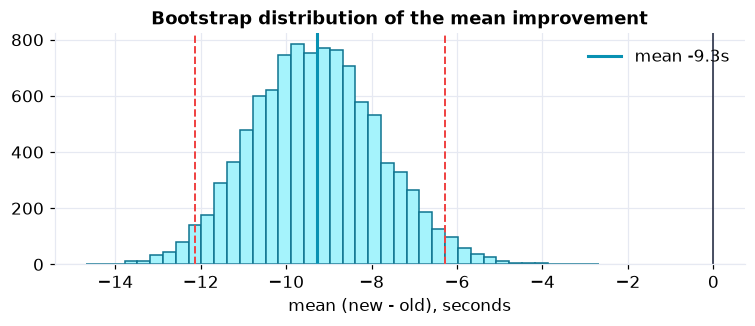

In [4]:
boot = np.array([rng.choice(d, size=n, replace=True).mean() for _ in range(10000)])
blo, bhi = np.percentile(boot, [2.5, 97.5])
tlo, thi = stats.t.interval(0.95, n-1, loc=d.mean(), scale=stats.sem(d))
print(f"bootstrap 95% CI for the mean improvement = [{blo:.2f}, {bhi:.2f}] s")
print(f"t-based 95% CI (from the chapter)         = [{tlo:.2f}, {thi:.2f}] s   (they agree closely)")
fig, ax = plt.subplots(figsize=(7,3.1))
ax.hist(boot, bins=40, color=LIGHT, edgecolor=DEEP)
ax.axvline(0, color=INK, lw=1); ax.axvline(d.mean(), color=EM, lw=2, label=f'mean {d.mean():.1f}s')
for x in (blo,bhi): ax.axvline(x, color=RED, ls='--', lw=1.3)
ax.set(title='Bootstrap distribution of the mean improvement', xlabel='mean (new - old), seconds'); ax.legend()
plt.tight_layout(); plt.show()

The bootstrap interval sits right on top of the t-based one and, crucially, the **entire interval is below zero**: even the optimistic end still has the new design several seconds faster. Two routes to the same interval, one assuming a t-distribution and one assuming nothing, is exactly the agreement you want before quoting a number.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">EXTENSION 4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The power of pairing, quantified</div>
<div style="color:#4a5578;margin-top:6px">Simulate both designs and count the wins.</div>
</div>

The chapter showed that a between-groups analysis of the same data was far weaker. Here we quantify it by simulation: draw many studies at this effect size and this between-user spread, compare a **paired** design (same users, both conditions) against a **between-subjects** design (a different group of users for each design) at the same total sample size, and count how often each **detects** the effect. That fraction is statistical **power**.

In [5]:
eff = d.mean(); sig = d.std(ddof=1)/np.sqrt(2)      # per-measurement noise (diff SD = sig*sqrt(2))
sd_between = df[['old_design_seconds','new_design_seconds']].mean(axis=1).std(ddof=1)
def one_study():
    # PAIRED design: 45 users each do BOTH conditions (each is their own control)
    base = rng.normal(60, sd_between, n)
    p_pair = stats.ttest_rel(base + eff + rng.normal(0,sig,n), base + rng.normal(0,sig,n)).pvalue
    # BETWEEN-SUBJECTS design: 45 DIFFERENT users, split into two groups (no pairing possible)
    h = n//2
    g_old = rng.normal(60, sd_between, h)       + rng.normal(0, sig, h)
    g_new = rng.normal(60, sd_between, n-h)+eff + rng.normal(0, sig, n-h)
    p_bs  = stats.ttest_ind(g_new, g_old).pvalue
    return p_pair < 0.05, p_bs < 0.05
res = np.array([one_study() for _ in range(2000)])
print(f"power of the PAIRED design        = {res[:,0].mean()*100:.0f}%   (same 45 users, both designs)")
print(f"power of a BETWEEN-SUBJECTS design = {res[:,1].mean()*100:.0f}%   (45 different users split into two groups)")
print("Same total sample and effect: pairing cancels the between-user spread and buys a large jump in power.")

power of the PAIRED design        = 100%   (same 45 users, both designs)
power of a BETWEEN-SUBJECTS design = 40%   (45 different users split into two groups)
Same total sample and effect: pairing cancels the between-user spread and buys a large jump in power.


At this effect size and sample, the **paired** design detects the improvement nearly every time, while the **between-subjects** design misses it a large share of the time. Pairing is not a statistical nicety; it is the difference between a study that reliably answers the question and one that often comes back inconclusive. Whenever the same subjects can be measured under both conditions, pairing is usually the most powerful design available.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">EXTENSION 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Who did not benefit?</div>
<div style="color:#4a5578;margin-top:6px">A bimodal difference points at a real question.</div>
</div>

Step 10 of the chapter found two clusters: big improvers and near-zero changers. That split is worth taking seriously, because it may reveal where the redesign helps and where it does not. Here we characterize the two groups by their baseline speed, a first clue about who the non-responders are.

                  users  mean_improvement  mean_baseline
group                                                   
little/no change     14               3.1           62.8
responder            31             -14.9           55.6


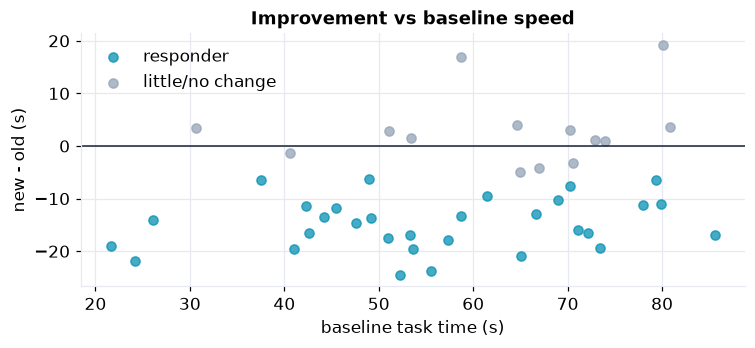

In [6]:
df['baseline'] = df[['old_design_seconds','new_design_seconds']].mean(axis=1)
df['group'] = np.where(df['diff'] < -5, 'responder', 'little/no change')
print(df.groupby('group').agg(users=('diff','size'), mean_improvement=('diff','mean'), mean_baseline=('baseline','mean')).round(1))
fig, ax = plt.subplots(figsize=(7,3.3))
for grp, c in [('responder', EM), ('little/no change', GREY)]:
    s = df[df.group==grp]; ax.scatter(s.baseline, s['diff'], color=c, alpha=0.75, label=grp)
ax.axhline(0, color=INK, lw=1); ax.set(title='Improvement vs baseline speed', xlabel='baseline task time (s)', ylabel='new - old (s)'); ax.legend()
plt.tight_layout(); plt.show()

Splitting at a five-second improvement, most users are clear responders while a minority barely move. Plotting each user's improvement against their baseline speed is the start of an answer: if the non-responders cluster among the already-fast users, the redesign mainly helps slower users, a finding a product team can act on. This is exploratory (chosen after seeing the data), so treat it as a hypothesis to test in the next study, not a conclusion.

---
**The one idea to keep: when the same subjects can be measured under both conditions, pair them, because using each subject as their own control cancels the between-subject variance that otherwise hides the effect, and then match the test to the differences (t if normal, Wilcoxon or the sign test if not).**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>